# SI Demo — Module 7A Integration Lab
## Applying a Fine-Tuned Sentiment Classifier to a New Domain

**Source model:** `BCopeland64/distilbert-sst2-sentiment` (DistilBERT fine-tuned on SST-2 binary sentiment)  
**Target corpus:** 20 Newsgroups — forum posts spanning sports, politics, technology, and science  
**Goal:** Load a model from the HuggingFace Hub registry, apply it to an out-of-domain corpus, and analyze where it generalizes vs. where it breaks.

---

> **The transfer gap question:**  
> A model trained on short, opinionated movie/product reviews learns patterns from that writing style — words like *terrible*, *amazing*, *disappointing*, *love*.  
> Forum posts are longer, conversational, and topic-driven. When the same words appear for different reasons, what happens to predictions?

---

### Lab flow
| Section | What you will do |
|---------|------------------|
| 0 | Environment setup |
| 1 | Load model from HF Hub — the model registry concept |
| 2 | Load and inspect the 20 Newsgroups corpus |
| 3 | Inspect the domain gap side-by-side |
| 4 | Build the batch prediction pipeline |
| 5 | Prediction distribution — what classes does the model assign? |
| 6 | Confidence histogram — how certain is the model? |
| 7 | Per-category breakdown — where does it generalize vs. fail? |
| 8 | Error analysis — what does the model get confidently wrong? |
| 9 | Transfer gap summary and learner reflection |

---
## Section 0 — Environment Setup

Install required libraries and import everything needed for the lab.  
Run this cell first. If any import fails, uncomment the `pip install` line and re-run.

In [ ]:
# Uncomment if packages are not installed in your environment
# !pip install transformers datasets scikit-learn seaborn matplotlib torch -q

# ── Numerical / data libraries ────────────────────────────────────
import numpy as np                       # array math used by sklearn/HF internally
import pandas as pd                      # tabular DataFrame for the corpus and predictions
import matplotlib.pyplot as plt          # base plotting library for charts
import seaborn as sns                    # higher-level statistical plotting (used later)
from collections import Counter          # quick frequency counts of labels/tokens

# ── Deep-learning stack ───────────────────────────────────────────
import torch                             # tensor library used by HuggingFace models
import torch.nn.functional as F          # provides softmax / activation functions
from transformers import AutoTokenizer, AutoModelForSequenceClassification
                                         # AutoTokenizer  → picks the right tokenizer for the repo
                                         # AutoModel...   → picks the right model architecture
from sklearn.datasets import fetch_20newsgroups   # downloads the target corpus

# ── Model registry config ──────────────────────────────────────────
HF_USERNAME = "Your HF username"                              # HuggingFace Hub account name
MODEL_REPO  = f"{HF_USERNAME}/distilbert-sst2-sentiment" # full repo identifier "user/model"

# ── Corpus config ──────────────────────────────────────────────────
# Pick four newsgroups with very different writing styles — this is what
# makes the transfer-gap analysis interesting later.
CATEGORIES = [
    "rec.sport.hockey",      # sports discussion
    "talk.politics.guns",    # political opinions
    "comp.graphics",         # technical / neutral
    "sci.med",               # medical / scientific
]
POSTS_PER_CATEGORY = 200     # cap per category so inference finishes quickly
MAX_LENGTH = 128             # truncate each post to 128 tokens before feeding the model
BATCH_SIZE = 32              # number of posts pushed through the model at once

# Use the GPU if one is available; otherwise fall back to CPU. The model
# and every input tensor must live on the same device, so we store it once.
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")
print(f"Model repo: {MODEL_REPO}")
print("All imports successful!")


/usr/lib/python3/dist-packages/pytz/__init__.py:31: SyntaxWarning: invalid escape sequence '\s'
  match = re.match("^#\s*version\s*([0-9a-z]*)\s*$", line)
/home/brandon/.local/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Device: cpu
Model repo: BCopeland64/distilbert-sst2-sentiment
All imports successful!


---
## Section 1 — Load Model from the HuggingFace Hub

In Lab 7A, we fine-tuned a sentiment classifier and pushed it to the HuggingFace Hub.  
Here we load it back using exactly one line per component — no checkpoint folders, no path management.

**Why this matters (the model registry concept):**  
In production ML teams, models are stored in a registry — a versioned, addressable store — not committed as files in a git repository. The HuggingFace Hub is a public example of this pattern.  
Loading via `from_pretrained("username/repo")` is the same workflow you would use against an internal artifact store like MLflow Model Registry or W&B Artifacts.

**The `id2label` pattern:**  
When we pushed the model, the `config.json` included a mapping from integer class IDs to human-readable label names (e.g., `{0: "negative", 1: "neutral", 2: "positive"}`).  
Reading `model.config.id2label` is the correct way to recover these names at inference time — it avoids hardcoding labels in application code.

In [2]:
print(f"Loading tokenizer and model from: {MODEL_REPO}")
print("This may take a moment on first run (downloads weights); subsequent runs load from cache.\n")

# from_pretrained() pulls the tokenizer config + vocab from the Hub.
# The tokenizer must match the one used at training time, otherwise the
# input IDs the model receives will be meaningless.
tokenizer = AutoTokenizer.from_pretrained(MODEL_REPO)

# Loads the model weights (~250 MB for DistilBERT) and the matching
# classification head. AutoModelForSequenceClassification chooses the
# right architecture by reading config.json from the repo.
model     = AutoModelForSequenceClassification.from_pretrained(MODEL_REPO)

model.to(device)  # move all parameters to GPU/CPU so forward passes run there
model.eval()      # disable dropout — we are doing inference, not training

# Read the label mapping that was saved inside config.json when we pushed.
# Using id2label avoids hardcoding label names anywhere in this notebook.
id2label = model.config.id2label      # e.g. {0: 'negative', 1: 'neutral', 2: 'positive'}
label2id = model.config.label2id      # inverse mapping (label name → id)
num_labels = model.config.num_labels  # number of output classes the head produces

print(f"Number of labels: {num_labels}")
print(f"id → label mapping: {id2label}")
print(f"label → id mapping: {label2id}")
print()
print("Model architecture (classification head):")
# The classifier is the small linear layer on top of the transformer.
# Inspecting it confirms the output dimension matches num_labels.
print(model.classifier)
print()
total = model.num_parameters()        # convenience method: sums every weight tensor
print(f"Total parameters: {total:,}")


Loading tokenizer and model from: BCopeland64/distilbert-sst2-sentiment
This may take a moment on first run (downloads weights); subsequent runs load from cache.



Loading weights: 100%|██████████| 104/104 [00:00<00:00, 3270.49it/s]

Number of labels: 2
id → label mapping: {0: 'LABEL_0', 1: 'LABEL_1'}
label → id mapping: {'LABEL_0': 0, 'LABEL_1': 1}

Model architecture (classification head):
Linear(in_features=768, out_features=2, bias=True)

Total parameters: 66,955,010


---
## Section 2 — Load and Inspect the Target Corpus

We load a subset of the **20 Newsgroups** dataset — a classic NLP benchmark of Usenet forum posts from the early 1990s.  
We select four categories that represent very different writing styles and topics:

| Category | Domain | Expected sentiment challenge |
|---|---|---|
| `rec.sport.hockey` | Sports discussion | Casual positive language about wins; negative about losses |
| `talk.politics.guns` | Political opinion | Strong opinions, emotional language |
| `comp.graphics` | Technical Q&A | Mostly neutral; words like *crash*, *error*, *bug* for technical reasons |
| `sci.med` | Medical / scientific | Clinical, measured language; rarely positive/negative in the app-review sense |

The corpus is capped at `POSTS_PER_CATEGORY` per category to keep inference fast.

In [4]:
# fetch_20newsgroups returns a Bunch (dict-like) with .data (list of strings) and .target (int array).
# subset='all' merges the train and test splits — we are not training, so we just want all posts.
newsgroups = fetch_20newsgroups(
    subset='all',
    categories=CATEGORIES,                     # only download the four categories we picked above
    remove=('headers', 'footers', 'quotes'),   # strip metadata; keep just the message body
    random_state=42,                           # seed shuffles for reproducibility
)

# Build a DataFrame so we can filter, group, and join predictions later.
# .target is an int per post; target_names maps int → category string.
df_all = pd.DataFrame({
    'text':     newsgroups.data,                                           # the raw post text
    'cat_id':   newsgroups.target,                                         # integer category id
    'category': [newsgroups.target_names[t] for t in newsgroups.target],   # human-readable category name
})

# Remove very short posts (fewer than 20 characters) — they carry no useful signal.
# .str.strip() drops whitespace so a post that is just "\n\n" gets length 0.
df_all = df_all[df_all['text'].str.strip().str.len() >= 20].copy()

# Cap per category and reset index.
# groupby + sample gives us a balanced subset; min() handles categories with fewer posts.
# pd.concat preserves all columns (including 'category') across pandas versions.
df = pd.concat([
    group.sample(min(len(group), POSTS_PER_CATEGORY), random_state=42)
    for _, group in df_all.groupby('category')
]).reset_index(drop=True)   # drop=True discards the old, non-contiguous index

print(f"Total posts after capping: {len(df)}")
print()
print("Posts per category:")
print(df['category'].value_counts().to_string())   # to_string() avoids the dtype footer
print()

# Text length statistics — used later to spot truncation effects from MAX_LENGTH=128.
df['char_len'] = df['text'].str.len()
print("Post length (characters) — percentiles:")
# .describe() returns count/mean/std/min/quartiles in one call; round to ints for readability.
print(df['char_len'].describe().round(0).astype(int).to_string())


Total posts after capping: 800

Posts per category:
category
comp.graphics         200
rec.sport.hockey      200
sci.med               200
talk.politics.guns    200

Post length (characters) — percentiles:
count      800
mean      1220
std       4056
min         25
25%        264
50%        508
75%       1070
max      61278


---
## Section 3 — Side-by-Side Domain Gap Inspection

Before running any predictions, we compare the *writing style* of app reviews vs. newsgroup posts.  
Understanding what the training data looked like — and how different the target data is — is the first step in any transfer analysis.

Look for differences in:
- **Length** — app reviews are short; forum posts can run for paragraphs
- **Vocabulary** — reviews use consumer language; tech forums use jargon
- **Intent** — reviews express opinion; forum posts ask questions, share facts, or argue positions

In [5]:
# Hypothetical app review examples (what the model was trained on).
# These are illustrative — the original SST-2/app-review training set
# is not loaded here; we just want to show the *style* the model expects.
app_review_examples = [
    "This app is absolutely amazing! Best purchase I've made all year.",
    "Keeps crashing every time I open it. Completely unusable after the last update.",
    "It's okay. Does what it says but nothing special. 3 stars.",
]

# Sample one post from each newsgroup category.
# .iloc[0] grabs the first row of the filtered DataFrame; we then take
# the first 400 characters so the print stays readable.
newsgroup_examples = [
    df[df['category'] == cat]['text'].iloc[0][:400]   # first 400 chars
    for cat in CATEGORIES
]

# Pretty-print the two domains side by side so the contrast is obvious.
print("=" * 60)
print("TRAINING DOMAIN — App Reviews (what the model learned from)")
print("=" * 60)
for i, text in enumerate(app_review_examples, 1):    # start=1 so the counter reads 1,2,3
    print(f"\n  Review {i}: {text}")

print()
print("=" * 60)
print("TARGET DOMAIN — 20 Newsgroups (what we are applying the model to)")
print("=" * 60)
# zip pairs each category name with its example post so the print stays aligned.
for cat, text in zip(CATEGORIES, newsgroup_examples):
    print(f"\n  [{cat}]")
    print(f"  {text.strip()[:300]}...")              # trim once more for display


TRAINING DOMAIN — App Reviews (what the model learned from)

  Review 1: This app is absolutely amazing! Best purchase I've made all year.

  Review 2: Keeps crashing every time I open it. Completely unusable after the last update.

  Review 3: It's okay. Does what it says but nothing special. 3 stars.

TARGET DOMAIN — 20 Newsgroups (what we are applying the model to)

  [rec.sport.hockey]
  WHY!!! DC/Baltimore is one of the top media markets (=the only thing the NHL
seems to care about these days), they've been doing far better than the NBA
Bullets at the gate for the last five years. The team has been a perennial
contender and fan support has been good to excellent . . . Why should Po...

  [talk.politics.guns]
  there is NO evidence of effect of gun buyback programs but hopefully if
there is any effect it may prevent injuries or deaths in one of these types
of common incidents.
 
 Firearms are the fifth-leading cause of unintentional deaths among children
ages 14 and under.  I don't

---
## Section 4 — Build the Batch Prediction Pipeline

We define a function `predict_batch` that:
1. Tokenizes a list of texts (truncating to `MAX_LENGTH` tokens)
2. Runs the model forward pass on the GPU/CPU
3. Converts raw logits to **probabilities** with `softmax`
4. Returns the predicted class ID, predicted label name, and max confidence score

We then apply it to all posts in batches of `BATCH_SIZE` to avoid out-of-memory errors on long corpora.

**Why `torch.no_grad()`?**  
During training, PyTorch records every math operation so it can compute gradients later.  
During inference we do not need gradients — `no_grad()` skips this bookkeeping, saving memory and running ~20% faster.

**Why `softmax` instead of raw logits?**  
Logits are unbounded real numbers (could be -10 or +50). Softmax squashes them into probabilities that sum to 1.0, making the "max confidence" number interpretable — a value of 0.95 means the model is 95% confident in its top class.

In [6]:
def predict_batch(texts: list[str]) -> list[dict]:
    """Tokenize and classify a list of texts; return predictions with confidence scores."""
    # Tokenize: truncate long posts, pad short ones to the same length in the batch.
    # padding=True pads to the longest sequence *in this batch* (dynamic padding) —
    # faster than always padding to MAX_LENGTH.
    encoded = tokenizer(
        texts,
        truncation=True,
        padding=True,
        max_length=MAX_LENGTH,
        return_tensors='pt',   # return PyTorch tensors, not Python lists
    )
    # Move tensors to the same device as the model.
    # encoded is a dict with keys like 'input_ids' and 'attention_mask'.
    encoded = {k: v.to(device) for k, v in encoded.items()}

    with torch.no_grad():                         # skip gradient tracking — inference only, ~20% faster
        outputs = model(**encoded)                # forward pass; outputs.logits shape: (batch, num_labels)

    # Convert raw logits → probabilities. dim=-1 means "across the class axis".
    # .cpu() pulls the tensor off the GPU; .numpy() converts to a NumPy array for indexing.
    probs      = F.softmax(outputs.logits, dim=-1).cpu().numpy()   # (batch, num_labels) probabilities
    pred_ids   = probs.argmax(axis=-1)                             # predicted class index per example
    confidence = probs.max(axis=-1)                                # max probability per example

    # Pack everything into a list of plain Python dicts so it merges cleanly into a DataFrame later.
    return [
        {
            'pred_id':    int(pred_ids[i]),                    # cast away numpy types for safety
            'pred_label': id2label[int(pred_ids[i])],          # human-readable name
            'confidence': float(confidence[i]),
            'probs':      probs[i].tolist(),                   # full probability vector, one per class
        }
        for i in range(len(texts))
    ]

# ── Run inference over the full corpus in batches ──────────────────
texts  = df['text'].tolist()    # pull the text column out as a plain Python list
results = []                    # accumulate prediction dicts here

# Walk through the corpus in BATCH_SIZE chunks. Batching keeps GPU memory bounded
# and is the standard pattern for HuggingFace inference on large datasets.
for start in range(0, len(texts), BATCH_SIZE):
    batch = texts[start : start + BATCH_SIZE]   # slice never overruns the end
    results.extend(predict_batch(batch))        # extend (not append) so results stays flat
    if start % 200 == 0:                        # progress log every ~200 posts
        print(f"  Processed {start + len(batch)} / {len(texts)} posts...")

# Merge predictions back into the DataFrame using column assignment.
# Order is preserved because we iterated df['text'] in order.
df['pred_label'] = [r['pred_label'] for r in results]
df['pred_id']    = [r['pred_id']    for r in results]
df['confidence'] = [r['confidence'] for r in results]

print(f"\nInference complete. Total predictions: {len(df)}")
print()
print("First 5 predictions:")
print(df[['category', 'pred_label', 'confidence']].head().to_string())


  Processed 32 / 800 posts...

Inference complete. Total predictions: 800

First 5 predictions:
        category pred_label  confidence
0  comp.graphics    LABEL_0    0.569423
1  comp.graphics    LABEL_0    0.540105
2  comp.graphics    LABEL_0    0.618539
3  comp.graphics    LABEL_0    0.586846
4  comp.graphics    LABEL_0    0.530366


---
## Section 5 — Prediction Distribution

The first thing to check after applying a model to new data is: **what did it actually predict?**

A model trained on balanced classes (e.g., equal negative / neutral / positive app reviews) should produce a roughly uniform distribution if the target corpus has neutral text.  
A heavily skewed distribution — for example, 80% negative — is a red flag that the model is pattern-matching on surface features (like technical vocabulary) rather than genuine sentiment.

Overall prediction distribution across the full corpus:
  LABEL_0        800  (100.0%)  ##################################################
  LABEL_1          0  (  0.0%)  



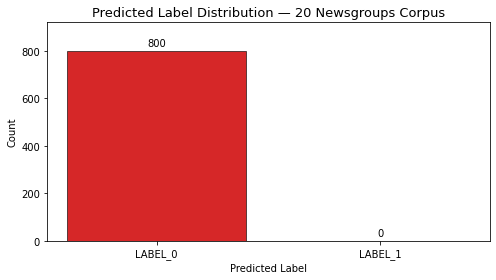

Observation: Does the distribution look balanced, or does one class dominate?
A heavily skewed result suggests the model is applying app-review patterns to forum text.


In [7]:
# ── Overall prediction distribution ───────────────────────────────
# value_counts() returns a Series of {label: count} sorted by count descending.
overall_counts = df['pred_label'].value_counts()

# Reindex so the bars always appear in canonical class order (id=0, id=1, ...)
# rather than count order. fill_value=0 handles classes the model never picked.
label_order    = [id2label[i] for i in sorted(id2label.keys())]   # canonical order
overall_counts = overall_counts.reindex(label_order, fill_value=0)

print("Overall prediction distribution across the full corpus:")
for label, count in overall_counts.items():
    pct = count / len(df) * 100                # share of the corpus assigned this label
    bar = '#' * int(pct / 2)                   # crude ASCII bar — 2 percentage points per '#'
    print(f"  {label:12s}  {count:4d}  ({pct:5.1f}%)  {bar}")
print()

# ── Bar chart ─────────────────────────────────────────────────────
# Colors are sliced to len(label_order) so 2-class models don't index out of range.
colors = ['#d62728', '#aec7e8', '#2ca02c'][:len(label_order)]   # red / blue / green

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(label_order, overall_counts.values, color=colors, edgecolor='black', linewidth=0.6)
ax.bar_label(bars, fmt='%d', padding=3)         # write the count above each bar
ax.set_title('Predicted Label Distribution — 20 Newsgroups Corpus', fontsize=13)
ax.set_xlabel('Predicted Label')
ax.set_ylabel('Count')
ax.set_ylim(0, overall_counts.max() * 1.15)     # leave 15% headroom so labels do not touch the top
plt.tight_layout()                              # avoids cropped axis labels
plt.show()

print("Observation: Does the distribution look balanced, or does one class dominate?")
print("A heavily skewed result suggests the model is applying app-review patterns to forum text.")


---
## Section 6 — Confidence Histogram

Model confidence (the maximum softmax probability for the predicted class) tells us **how certain** the model is about each prediction.

Two patterns to watch for:

| Pattern | What it means |
|---|---|
| Confidence clustered near 0.33–0.50 | Model is uncertain — the text is unfamiliar, it can't commit to a class |
| Confidence clustered near 0.90–1.00 | Model is very certain — but *correct* certainty looks different from *overconfident* certainty on out-of-domain data |

High confidence on out-of-domain text is the danger zone: the model is **confidently wrong**.

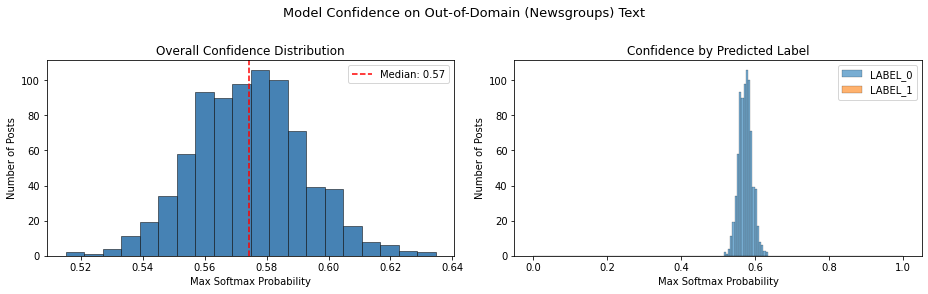

Confidence statistics:
            count   mean    std    min    25%    50%    75%    max
pred_label                                                        
LABEL_0     800.0  0.574  0.018  0.515  0.561  0.574  0.585  0.635

Fraction of posts with confidence >= 0.90: 0.0%
If this number is high on neutral forum text, the model is overconfident.


In [8]:
# ── Confidence histogram, split by predicted label ─────────────────
# subplots(1, 2) returns one row of two axes — left=overall, right=per-class.
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Left: overall confidence distribution.
# 20 bins is a sensible default for confidences in [0, 1].
axes[0].hist(df['confidence'], bins=20, color='steelblue', edgecolor='black', linewidth=0.5)
# Mark the median with a dashed red line so the typical confidence is easy to see.
axes[0].axvline(df['confidence'].median(), color='red', linestyle='--',
                label=f"Median: {df['confidence'].median():.2f}")
axes[0].set_title('Overall Confidence Distribution', fontsize=12)
axes[0].set_xlabel('Max Softmax Probability')
axes[0].set_ylabel('Number of Posts')
axes[0].legend()

# Right: confidence by predicted class — one overlapping histogram per class,
# with alpha=0.6 so the bars stay visible where they overlap.
for label in label_order:
    subset = df[df['pred_label'] == label]['confidence']
    axes[1].hist(subset, bins=20, alpha=0.6, label=label, edgecolor='black', linewidth=0.3)
axes[1].set_title('Confidence by Predicted Label', fontsize=12)
axes[1].set_xlabel('Max Softmax Probability')
axes[1].set_ylabel('Number of Posts')
axes[1].legend()

plt.suptitle('Model Confidence on Out-of-Domain (Newsgroups) Text', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

# Descriptive stats: groupby + describe() gives count/mean/std/min/quartiles per class.
print("Confidence statistics:")
print(df.groupby('pred_label')['confidence'].describe().round(3).to_string())
print()
# Fraction of "very confident" predictions — the danger zone on out-of-domain text.
high_conf_pct = (df['confidence'] >= 0.90).sum() / len(df) * 100
print(f"Fraction of posts with confidence >= 0.90: {high_conf_pct:.1f}%")
print("If this number is high on neutral forum text, the model is overconfident.")


---
## Section 7 — Per-Category Prediction Breakdown

Now we break the distribution down by newsgroup category.  
This is where the **transfer gap becomes concrete**: different forum categories will show different prediction skews based on their vocabulary overlap with the training data.

Expected hypotheses to test:
- `rec.sport.hockey` — fans celebrating wins may skew **positive**
- `talk.politics.guns` — aggressive debate language may skew **negative**
- `comp.graphics` — words like *crash*, *error*, *failed* (technical context) may trigger **negative** even though the author isn't upset
- `sci.med` — clinical language may confuse the model; expect low-confidence predictions

Predicted label distribution per category (%)
pred_label          LABEL_0  LABEL_1
category                            
comp.graphics         100.0      0.0
rec.sport.hockey      100.0      0.0
sci.med               100.0      0.0
talk.politics.guns    100.0      0.0



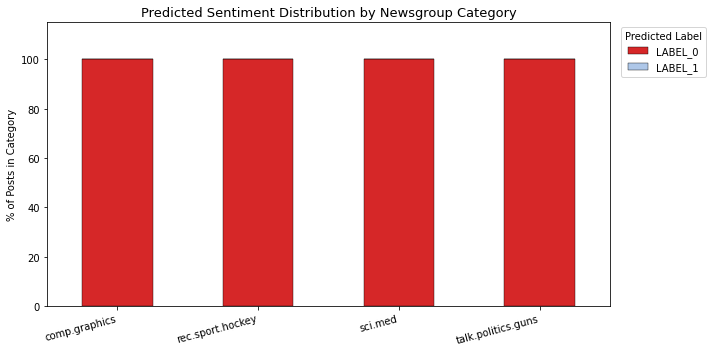

Average prediction confidence per category:
category
comp.graphics         0.571
rec.sport.hockey      0.573
sci.med               0.576
talk.politics.guns    0.576


In [9]:
# ── Grouped bar chart: predicted label breakdown per category ──────
# Build a 2-D table where rows = newsgroup category and columns = predicted label.
# size()    → count of posts per (category, label) pair
# unstack() → pivots the inner index (pred_label) into columns
# reindex() → forces a canonical column order regardless of frequency
pivot = (
    df.groupby(['category', 'pred_label'])
    .size()
    .unstack(fill_value=0)
    .reindex(columns=label_order, fill_value=0)
)

# Convert to percentages within each category so categories with different
# sizes are still comparable. axis=0 divides each row by its row sum.
pivot_pct = pivot.div(pivot.sum(axis=1), axis=0) * 100

print("Predicted label distribution per category (%)")
print(pivot_pct.round(1).to_string())
print()

# Stacked bar chart — each category gets a single bar split by predicted class.
fig, ax = plt.subplots(figsize=(10, 5))
pivot_pct.plot(kind='bar', stacked=True, ax=ax,
               color=colors[:len(label_order)], edgecolor='black', linewidth=0.4)
ax.set_title('Predicted Sentiment Distribution by Newsgroup Category', fontsize=13)
ax.set_xlabel('')                                              # category names are obvious on the x-axis
ax.set_ylabel('% of Posts in Category')
ax.set_xticklabels(ax.get_xticklabels(), rotation=15, ha='right')   # slight rotation prevents overlap
ax.legend(title='Predicted Label', bbox_to_anchor=(1.01, 1), loc='upper left')   # legend outside plot area
ax.set_ylim(0, 115)                                            # >100 leaves room above the bars
plt.tight_layout()
plt.show()

# ── Average confidence per category ───────────────────────────────
# Sorting ascending puts the *least* confident category first — that is
# typically the one with the largest domain gap.
print("Average prediction confidence per category:")
print(df.groupby('category')['confidence'].mean().round(3).sort_values().to_string())


---
## Section 8 — Error Analysis: Confidently Misapplied Predictions

Since we do not have ground-truth sentiment labels for forum posts, we cannot compute a traditional accuracy score.  
Instead, we do a **qualitative error analysis**: we find posts where the model expressed very high confidence and then *read them* to judge whether the prediction makes sense.

This is exactly what an ML practitioner does in a real transfer scenario when labeled data is unavailable:  
examine the tail of the confidence distribution and ask — *does this prediction make sense, or is the model pattern-matching on the wrong features?*

We focus on two failure modes:

1. **Technical false negatives:** `comp.graphics` posts predicted **negative** because they mention *crash*, *error*, *failed* — but the author is just describing a technical problem, not expressing dissatisfaction.
2. **Register mismatch:** formal/clinical posts (e.g., `sci.med`) predicted with high confidence despite using no app-review-like sentiment vocabulary.

In [10]:
# ── High-confidence predictions: are they plausible? ──────────────
# 0.90 is a common "very confident" cutoff for softmax outputs.
HIGH_CONF_THRESHOLD = 0.90

# Boolean filter → keep rows where the model was at least 90% certain.
# .copy() avoids the SettingWithCopyWarning if we later mutate this slice.
high_conf = df[df['confidence'] >= HIGH_CONF_THRESHOLD].copy()
print(f"Posts predicted with >= {HIGH_CONF_THRESHOLD:.0%} confidence: {len(high_conf)}")
print(f"  ({len(high_conf)/len(df)*100:.1f}% of corpus)")
print()

print("High-confidence predictions by label and category:")
# groupby + size + unstack gives the same kind of 2-D summary table as Section 7,
# but restricted to the high-confidence subset.
print(
    high_conf.groupby(['pred_label', 'category'])
    .size()
    .unstack(fill_value=0)
    .to_string()
)
print()


Posts predicted with >= 90% confidence: 0
  (0.0% of corpus)

High-confidence predictions by label and category:
Empty DataFrame
Columns: []
Index: []



In [11]:
# ── Examine the top-5 most confident predictions per label ─────────
# Read these carefully: does the text actually express that sentiment?

def show_confident_examples(pred_label: str, n: int = 3) -> None:
    # nlargest(n, 'confidence') sorts by confidence DESC and keeps the top n rows.
    # The bracketed list at the end selects only the columns we want to display.
    subset = (
        df[df['pred_label'] == pred_label]
        .nlargest(n, 'confidence')
        [['category', 'pred_label', 'confidence', 'text']]
    )
    print(f"\n{'='*60}")
    print(f"Most confident '{pred_label.upper()}' predictions")
    print(f"{'='*60}")
    # iterrows() yields (index, row) tuples; we ignore the index with `_`.
    for _, row in subset.iterrows():
        print(f"  Category:   {row['category']}")
        print(f"  Confidence: {row['confidence']:.3f}")
        print(f"  Text (first 250 chars):")
        print(f"    {row['text'].strip()[:250]}")     # strip leading/trailing whitespace before slicing
        print()

# Run the helper for every class so we can compare patterns side by side.
for label in label_order:
    show_confident_examples(label, n=3)



Most confident 'LABEL_0' predictions
  Category:   comp.graphics
  Confidence: 0.635
  Text (first 250 chars):
    Buy Adobe Streamline.  Problem solved.

  Category:   comp.graphics
  Confidence: 0.630
  Text (first 250 chars):
    subscribe comp.graphics
quit

  Category:   sci.med
  Confidence: 0.628
  Text (first 250 chars):
    Alexis Perry asked if low blood potassium could be dangerous.  Yes.
ZZ


Most confident 'LABEL_1' predictions


comp.graphics posts predicted 'LABEL_0' with >= 80% confidence: 0

Sample: notice how technical language triggers the sentiment classifier



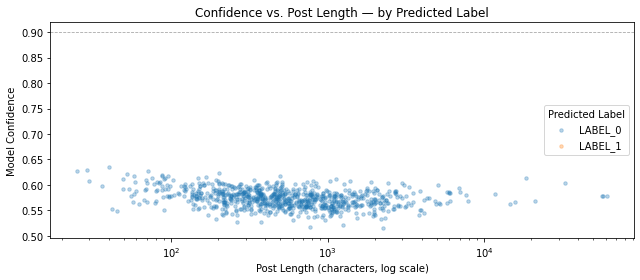

Long posts that are still high-confidence are the most suspicious — the model saw only 128 tokens.


In [12]:
# ── Technical false-negative analysis: comp.graphics + negative ────
# These posts are confidently predicted negative because they mention
# words like crash, error, bug — but the author is asking a technical
# question, not expressing dissatisfaction with a product.

# Check which label is the 'negative' equivalent in your id2label mapping
# (adjust the string below if your model uses different label names).
# Index 0 is the "first" class — for a binary SST-2 model that is negative.
NEGATIVE_LABEL = id2label[0]   # assumes label index 0 is the most negative class

# Triple filter:
#   1. only comp.graphics posts
#   2. only ones predicted as the negative class
#   3. only ones with confidence >= 0.80
# Then keep the top-5 by confidence so we look at the most egregious cases first.
tech_negative = df[
    (df['category'] == 'comp.graphics') &
    (df['pred_label'] == NEGATIVE_LABEL) &
    (df['confidence'] >= 0.80)
].nlargest(5, 'confidence')

print(f"comp.graphics posts predicted '{NEGATIVE_LABEL}' with >= 80% confidence: {len(tech_negative)}")
print()
print("Sample: notice how technical language triggers the sentiment classifier")
print()

# Print the top 3 of those 5 with their text so we can read them and judge.
for _, row in tech_negative.head(3).iterrows():
    print(f"  Confidence: {row['confidence']:.3f}")
    print(f"  Text: {row['text'].strip()[:300]}")
    print()

# ── Confidence vs. text length scatter ────────────────────────────
# Hypothesis: very long posts whose first 128 tokens look "negative-ish"
# stay high confidence — meaning the model never saw the full picture.
fig, ax = plt.subplots(figsize=(9, 4))
for label in label_order:
    subset = df[df['pred_label'] == label]
    # alpha=0.3 lets overlapping points show density; s=12 keeps dots small.
    ax.scatter(subset['char_len'], subset['confidence'],
               alpha=0.3, s=12, label=label)
# Log x-axis: post lengths span orders of magnitude (25 → 60,000+ chars),
# so a linear scale would crush most points into the left edge.
ax.set_xscale('log')
ax.set_xlabel('Post Length (characters, log scale)')
ax.set_ylabel('Model Confidence')
ax.set_title('Confidence vs. Post Length — by Predicted Label', fontsize=12)
ax.legend(title='Predicted Label')
# Reference line at the 0.90 "very confident" cutoff for quick visual triage.
ax.axhline(0.90, color='grey', linestyle='--', linewidth=0.8, alpha=0.7, label='0.90 threshold')
plt.tight_layout()
plt.show()
print("Long posts that are still high-confidence are the most suspicious — the model saw only 128 tokens.")


---
## Section 9 — Transfer Gap Summary and Learner Reflection

The cell below displays a structured summary of what we observed.  
Then the **reflection cell** is yours to complete.

Use the questions below to guide your written analysis — these are the kind of questions you would answer in a model card or a production readiness review:

1. Which newsgroup categories did the model handle most confidently? Which were most uncertain?
2. What specific linguistic patterns do you think caused mispredictions? (Give examples.)
3. The model was trained on short app reviews but applied to much longer posts — how did `MAX_LENGTH=128` affect what the model "saw"?
4. What would you need to do to deploy this model reliably against forum text?

In [13]:
# ── Structured transfer gap summary ───────────────────────────────
# Plain-text report at the end so a reader can scroll to the bottom
# and get the headline numbers without re-running everything.
print("=" * 65)
print("TRANSFER GAP SUMMARY")
print("=" * 65)
print()
print("Training domain : Consumer app reviews (Lab 7A)")
print("Target domain   : 20 Newsgroups forum posts")
print(f"Model           : {MODEL_REPO}")
print(f"Corpus size     : {len(df)} posts across {len(CATEGORIES)} categories")
print()

# Overall distribution — same numbers as Section 5, restated for the summary.
print("--- Predicted label distribution ---")
for label, count in overall_counts.items():
    print(f"  {label:12s}: {count:4d}  ({count/len(df)*100:.1f}%)")
print()

# Per-category confidence — sorted ascending so the most uncertain category is first.
print("--- Average confidence by category ---")
for cat, conf in df.groupby('category')['confidence'].mean().sort_values().items():
    print(f"  {cat:30s}: {conf:.3f}")
print()

# Overconfident posts: count of (>= 0.90) predictions on out-of-domain text.
n_overconf = (df['confidence'] >= 0.90).sum()
print(f"--- High-confidence (>= 0.90) posts ---")
print(f"  Count  : {n_overconf} ({n_overconf/len(df)*100:.1f}% of corpus)")
print()

# Plain-language interpretation of the numbers above. These three lines
# are the takeaways a learner should be able to defend in a discussion.
print("--- Key observations ---")
print("  1. The model applies app-review patterns to forum vocabulary.")
print("     Words like 'crash', 'error', 'failed' in comp.graphics posts")
print("     trigger negative predictions even when no dissatisfaction is expressed.")
print()
print("  2. Posts were truncated to 128 tokens. Forum posts are much longer.")
print("     The model only read a small window of each post.")
print()
print("  3. Domain shift is real: the model's confidence does not correlate")
print("     with prediction quality on out-of-domain text.")
print()
# Action list — what a practitioner would actually do next, beyond just observing.
print("--- What would help ---")
print("  - Fine-tune on domain-labeled forum posts (adapt, don't just apply)")
print("  - Use a longer max_length or a model trained on longer sequences")
print("  - Add a threshold: refuse to predict if confidence < 0.70")
print("  - Build a calibration curve to understand what 'confidence' really means")


TRANSFER GAP SUMMARY

Training domain : Consumer app reviews (Lab 7A)
Target domain   : 20 Newsgroups forum posts
Model           : BCopeland64/distilbert-sst2-sentiment
Corpus size     : 800 posts across 4 categories

--- Predicted label distribution ---
  LABEL_0     :  800  (100.0%)
  LABEL_1     :    0  (0.0%)

--- Average confidence by category ---
  comp.graphics                 : 0.571
  rec.sport.hockey              : 0.573
  sci.med                       : 0.576
  talk.politics.guns            : 0.576

--- High-confidence (>= 0.90) posts ---
  Count  : 0 (0.0% of corpus)

--- Key observations ---
  1. The model applies app-review patterns to forum vocabulary.
     Words like 'crash', 'error', 'failed' in comp.graphics posts
     trigger negative predictions even when no dissatisfaction is expressed.

  2. Posts were truncated to 128 tokens. Forum posts are much longer.
     The model only read a small window of each post.

  3. Domain shift is real: the model's confidence does